In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [2]:
import os

dataset_path = "/kaggle/input/chest-xray-pneumonia"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/kaggle/input/chest-xray-pneumonia
/kaggle/input/chest-xray-pneumonia/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_x

In [4]:
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
test_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
train_dataset_full = ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset_full = ImageFolder(
    train_dir,
    transform=val_transform
)

In [12]:
targets = train_dataset_full.targets

train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

The dataset is imbalanced:

NORMAL ≈ 1,341 images<br>
PNEUMONIA ≈ 3,875 images

Without stratification, we might end up with a validation set that has too many images from one class. Stratification keeps the class proportions nearly the same in both training and validation sets

In [11]:
train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

In [16]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [17]:
test_dataset = ImageFolder(
    test_dir,
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [18]:
print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Test Images       : {len(test_dataset)}")

print("\nClasses:", train_dataset_full.classes)
print("Class Mapping:", train_dataset_full.class_to_idx)

Training Images   : 4172
Validation Images : 1044
Test Images       : 624

Classes: ['NORMAL', 'PNEUMONIA']
Class Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [19]:
import torch.nn as nn
from torchvision import models

In [21]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


In [22]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [24]:
model.fc=nn.Linear(
    in_features=model.fc.in_features,
    out_features=2
)

In [25]:
for param in model.parameters():
    param.requires_grad = False

In [26]:
for param in model.fc.parameters():
    param.requires_grad = True

In [27]:
model=model.to(device)

In [28]:
model.fc

Linear(in_features=512, out_features=2, bias=True)

In [29]:
criterion=nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

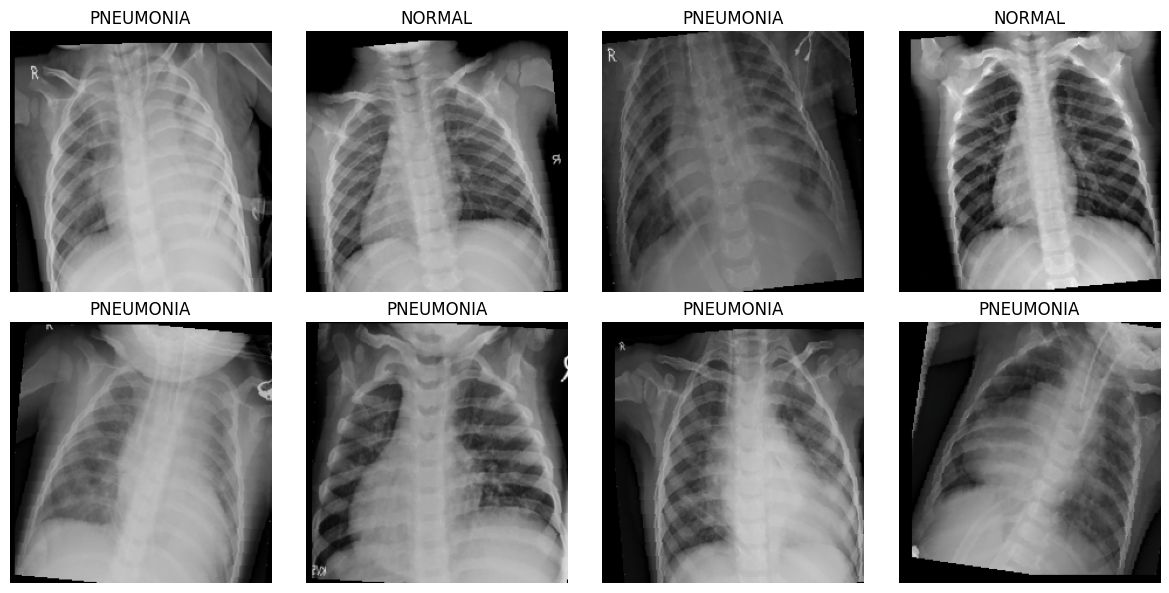

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(iter(train_loader))

# Class names
classes = train_dataset_full.classes

# Mean and std used for normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Create a 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()   # CHW -> HWC

    # Unnormalize
    img = img * std + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(classes[labels[i].item()], fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [33]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [34]:
def validate(model, val_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [36]:
num_epochs = 10

train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_resnet18.pth"
        )

        print("Best model saved!")

    print("-"*50)

Epoch [1/10]
Train Loss : 0.3363
Train Acc  : 85.43%
Val Loss   : 0.2130
Val Acc    : 91.95%
Best model saved!
--------------------------------------------------
Epoch [2/10]
Train Loss : 0.2074
Train Acc  : 92.09%
Val Loss   : 0.1906
Val Acc    : 92.53%
Best model saved!
--------------------------------------------------
Epoch [3/10]
Train Loss : 0.1785
Train Acc  : 93.26%
Val Loss   : 0.1763
Val Acc    : 93.10%
Best model saved!
--------------------------------------------------
Epoch [4/10]
Train Loss : 0.1695
Train Acc  : 93.05%
Val Loss   : 0.1326
Val Acc    : 95.11%
Best model saved!
--------------------------------------------------
Epoch [5/10]
Train Loss : 0.1645
Train Acc  : 93.79%
Val Loss   : 0.1570
Val Acc    : 94.35%
--------------------------------------------------
Epoch [6/10]
Train Loss : 0.1585
Train Acc  : 93.79%
Val Loss   : 0.2106
Val Acc    : 91.86%
--------------------------------------------------
Epoch [7/10]
Train Loss : 0.1543
Train Acc  : 94.13%
Val Loss   

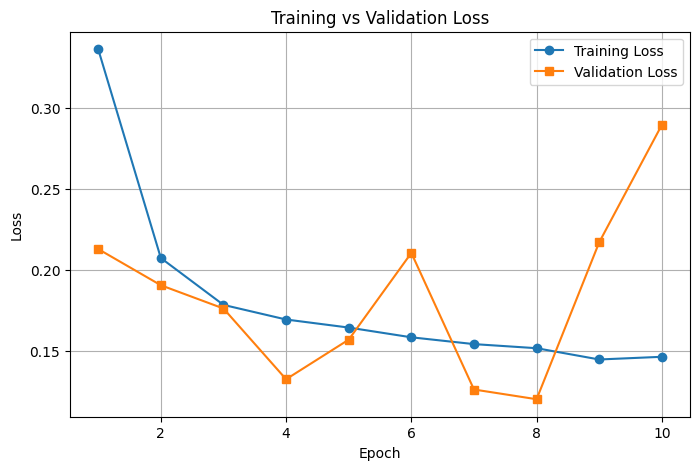

In [37]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

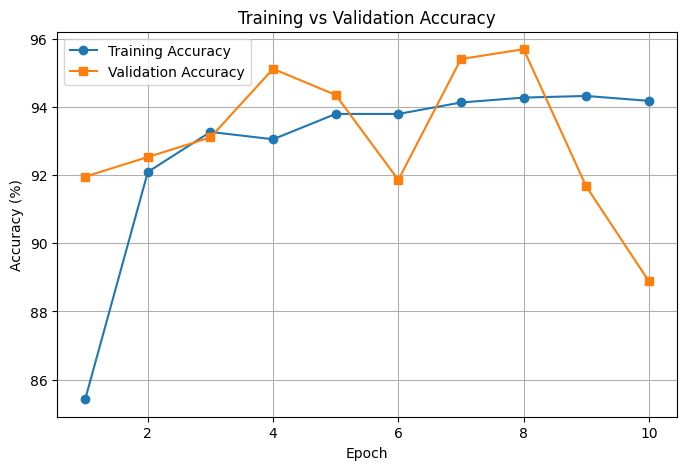

In [38]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_accs, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accs, marker='s', label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.show()

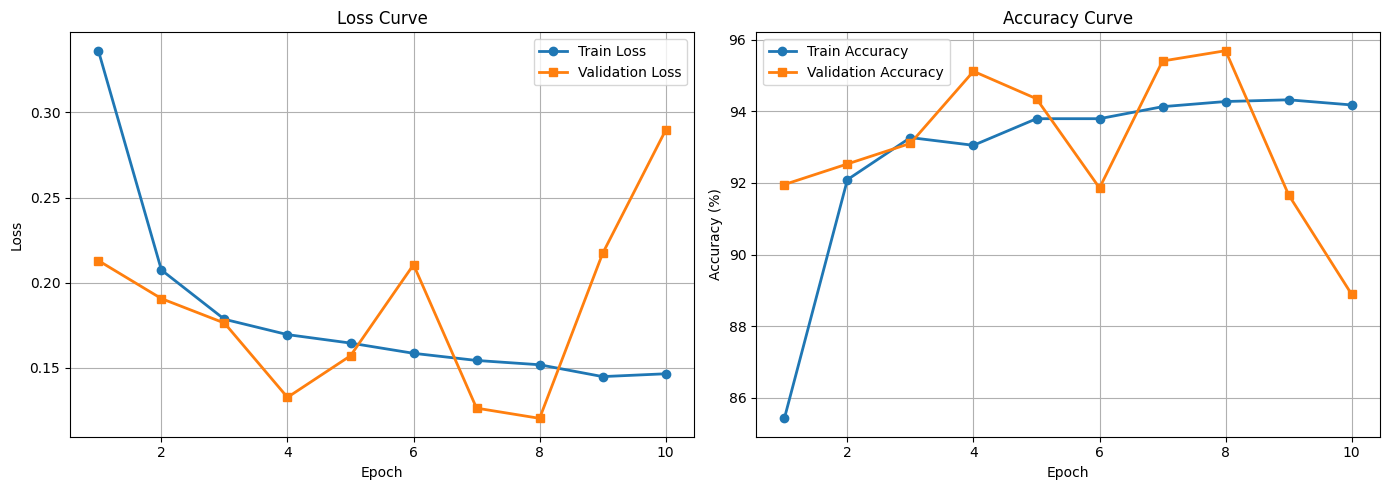

In [39]:
plt.figure(figsize=(14,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o', linewidth=2, label='Train Loss')
plt.plot(epochs, val_losses, marker='s', linewidth=2, label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(epochs, val_accs, marker='s', linewidth=2, label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
model.load_state_dict(torch.load("best_resnet18.pth"))
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [42]:
model.load_state_dict(torch.load("best_resnet18.pth", weights_only=True))
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [43]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
def test_model(model, test_loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    test_loss = running_loss / len(test_loader)

    accuracy = accuracy_score(all_labels, all_predictions)

    precision = precision_score(all_labels, all_predictions)

    recall = recall_score(all_labels, all_predictions)

    f1 = f1_score(all_labels, all_predictions)

    return (
        test_loss,
        accuracy,
        precision,
        recall,
        f1,
        all_labels,
        all_predictions
    )

In [45]:
test_loss, test_acc, precision, recall, f1, labels, predictions = test_model(
    model,
    test_loader,
    criterion,
    device
)

In [46]:
print("="*50)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc*100:.2f}%")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

print("="*50)

Test Loss      : 0.3854
Test Accuracy  : 86.06%
Precision      : 0.8301
Recall         : 0.9769
F1 Score       : 0.8975


In [47]:
print(classification_report(
    labels,
    predictions,
    target_names=test_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.95      0.67      0.78       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624



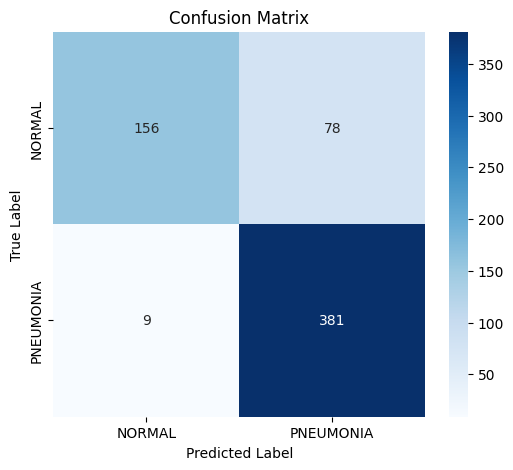

In [48]:
cm = confusion_matrix(labels, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [49]:
cm = confusion_matrix(labels, predictions)
print(cm)

[[156  78]
 [  9 381]]


In [50]:
model.load_state_dict(torch.load("best_resnet18.pth", weights_only=True))
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [51]:
for param in model.parameters():
    param.requires_grad = False

In [52]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [53]:
for param in model.fc.parameters():
    param.requires_grad = True

In [54]:
print("Trainable Parameters:\n")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable Parameters:

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [56]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [57]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

In [58]:
num_epochs = 10

best_val_acc = 0

train_losses = []
train_accs = []

val_losses = []
val_accs = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")
    print(f"Learning Rate : {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_resnet18_finetuned.pth"
        )

        print("Best Fine-Tuned Model Saved!")

    print("-" * 50)

Epoch [1/10]
Train Loss : 0.1233
Train Acc  : 95.42%
Val Loss   : 0.0580
Val Acc    : 98.08%
Learning Rate : 0.000100
Best Fine-Tuned Model Saved!
--------------------------------------------------
Epoch [2/10]
Train Loss : 0.0694
Train Acc  : 97.32%
Val Loss   : 0.0618
Val Acc    : 98.08%
Learning Rate : 0.000100
--------------------------------------------------
Epoch [3/10]
Train Loss : 0.0686
Train Acc  : 97.51%
Val Loss   : 0.0695
Val Acc    : 97.51%
Learning Rate : 0.000100
--------------------------------------------------
Epoch [4/10]
Train Loss : 0.0641
Train Acc  : 97.79%
Val Loss   : 0.0469
Val Acc    : 98.18%
Learning Rate : 0.000100
Best Fine-Tuned Model Saved!
--------------------------------------------------
Epoch [5/10]
Train Loss : 0.0445
Train Acc  : 98.32%
Val Loss   : 0.0420
Val Acc    : 98.28%
Learning Rate : 0.000100
Best Fine-Tuned Model Saved!
--------------------------------------------------
Epoch [6/10]
Train Loss : 0.0339
Train Acc  : 98.80%
Val Loss   : 0.

In [60]:
model.load_state_dict(torch.load("best_resnet18_finetuned.pth", weights_only=True))
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [61]:
test_loss, test_acc, precision, recall, f1, labels, predictions = test_model(
    model,
    test_loader,
    criterion,
    device
)

In [62]:
print("=" * 50)
print("Test Results")
print("=" * 50)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc * 100:.2f}%")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

print("=" * 50)

Test Results
Test Loss      : 0.8032
Test Accuracy  : 82.69%
Precision      : 0.7866
Recall         : 0.9923
F1 Score       : 0.8776


In [63]:
from collections import Counter

print("Train:", Counter(train_dataset_full.targets))
print("Test :", Counter(test_dataset.targets))

Train: Counter({1: 3875, 0: 1341})
Test : Counter({1: 390, 0: 234})


In [64]:
model.load_state_dict(torch.load("best_resnet18.pth", weights_only=True))

model.to(device)
model.eval()
test_loss, test_acc, precision, recall, f1, labels, predictions = test_model(
    model,
    test_loader,
    criterion,
    device
)

In [65]:
print("=" * 50)
print("Test Results")
print("=" * 50)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc * 100:.2f}%")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

print("=" * 50)

Test Results
Test Loss      : 0.3854
Test Accuracy  : 86.06%
Precision      : 0.8301
Recall         : 0.9769
F1 Score       : 0.8975
